<a href="https://colab.research.google.com/github/kanebako-s/olist-data-analysis/blob/main/Kaggle_Olist_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## おまじない。

In [1]:
# --- ライブラリのインポート ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

# --- グラフの見た目を整える ---
sns.set(style="whitegrid") # グラフにグリッド（網掛け）を出して見やすくする
plt.rcParams["figure.figsize"] = (10, 6) # グラフの基本サイズを少し大きくする

# --- データの表示設定 ---
pd.options.display.max_columns = None # 列数が多い時、省略（...）せずに全部表示する
pd.set_option('display.float_format', '{:.2f}'.format) # 小数点以下を2桁に固定して見やすくする

# --- 日本語化（重要！） ---
!pip install japanize-matplotlib
import japanize_matplotlib # これでグラフの日本語が「□」にならずに済む

# --- Worldcloudのインストール ---
!pip install wordcloud
from wordcloud import WordCloud

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 53.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize-matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=6bdc2d4f27e0dd8564250b37288a2f130b23129c9427bf3905b159061e1b144f
  Stored in directory: /root/.cache/pip/wheels/c1/f7/9b/418f19a7b9340fc16e071e89efc379aca68d40238b258df53d
Successfully built japanize-matplotlib


## ファイルの読み込み。

In [2]:
FILE_PATH = '/content/drive/MyDrive/Olist_Dateanalist_Learning' # ファイルの読み込みが自分専用になっている。あとで直しやすいようにしている。

customers_dataset = pd.read_csv(FILE_PATH + '/olist_customers_dataset.csv')
orders_dataset = pd.read_csv(FILE_PATH + '/olist_orders_dataset.csv')
order_reviews_dataset = pd.read_csv(FILE_PATH + '/olist_order_reviews_dataset.csv')



## それぞれのテーブルの中身を確認する。

In [3]:
# customers_dataset.head(0) # 注文番号と顧客の固有識別番号、顧客の州と街。


顧客データ（customers_dataset）の構造把握。
* ** 顧客の固有識別子の重複についての注意 ** customer_unique_idのデータが重複していたとしても、一回の注文で複数のものを頼んだ可能性もありECサイトを別日程で再利用したかどうかは本テーブルのみでは判別不能。

** 分析方針 **

真のリピート率は"orders_dataset"と結合後、"customer_unique_id"をキーとして"order_id"の数をカウントする。

"order_id"の数が１であれば「新規顧客」、

"order_id"の数が２以上であれば「リピーター」と定義する。

リピーターの1回目の注文の満足度スコアが高いことは想像がつきます。

新規顧客について、1回目の注文の満足度スコアが高いのに再利用してない人は注文物の品質は満足したが配送関係で信頼を損なった可能性がある。1回目の満足度スコアが高く配送時間のズレが大きい人は離脱しているかを確認する。

In [4]:
orders_dataset.head(3) # order_idを主キーとする注文履歴。注文申請時間から配達完了時間までの５種類のタイムスタンプ。
# タイムスタンプのデータ型を確認、修正。推定配達日と実際配達日のズレの計算で使いそうだから。

data_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for time_col in data_cols:
  orders_dataset[time_col] = pd.to_datetime(orders_dataset[time_col])

orders_dataset.head(3)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04


注文データ（orders_dataset）の構造確認と仮説の構築。

* ** 推定配達日と実際配達日にズレについて ** 推定配達日より二週間早くと届く場合もあれば、二週間遅く届く日もあることが確認できた。この推定配達日のズレは信頼性を損ない顧客満足度に影響すると予想できる。
* ** 配達時間について ** 配達時間は地域性に依存するものの、同じ地域内でも配達時間にばらつきがあり、それが顧客満足度に影響している可能性がある。

** 分析方針 **

* 推定配達日と実際配達日のズレの日数を算出し、満足度スコアとの相関を可視化し確認する。
* 「地域」ごとの配達時間の分散を算出し満足度スコアの低くなる特定の地域を探る。


In [5]:
order_reviews_dataset.head(20) # レビューの固有識別子、満足度スコア、コメント、レビュー作成時間、レビューに対する運営の回答時間。

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53
5,15197aa66ff4d0650b5434f1b46cda19,b18dcdf73be66366873cd26c5724d1dc,1,NaN,NaN,2018-04-13 00:00:00,2018-04-16 00:39:37
6,07f9bee5d1b850860defd761afa7ff16,e48aa0d2dcec3a2e87348811bcfdf22b,5,NaN,NaN,2017-07-16 00:00:00,2017-07-18 19:30:34
7,7c6400515c67679fbee952a7525281ef,c31a859e34e3adac22f376954e19b39d,5,NaN,NaN,2018-08-14 00:00:00,2018-08-14 21:36:06
8,a3f6f7f6f433de0aefbb97da197c554c,9c214ac970e84273583ab523dfafd09b,5,NaN,NaN,2017-05-17 00:00:00,2017-05-18 12:05:37
9,8670d52e15e00043ae7de4c01cc2fe06,b9bf720beb4ab3728760088589c62129,4,recomendo,aparelho eficiente. no site a marca do aparelh...,2018-05-22 00:00:00,2018-05-23 16:45:47


レビューデータ（order_reviews_dataset）の構造確認と評価指標の選定。

** レビューデータ確認による洞察 **
* ** 運営の対応速度について ** レビューが投稿されてから運営が回答するまでの時間はこの２０件の中では最大７日だった。このデータはリピート率に影響していなさそう。
* ** コメントをする人の割合について **コメントタイトルとコメントは書いている人の割合が少ない。一部のユーザーの意見で全体の傾向は測れないため指標として不適。

** 分析方針 **

レビューデータでは、満足度スコアのみを主要な指標にすることでリピート率の向上に役立てる。満足度スコア１がリピート率に与える影響を確認する。

In [6]:
# ３つのテーブルを一つにまとめる。
df_temp = pd.merge(orders_dataset, customers_dataset, on='customer_id')
df_final = pd.merge(df_temp, order_reviews_dataset, on='order_id')

## 分析・方向性の決定

In [7]:
# 満足度スコア１がリピート率に与える影響を確認する。
# スコア1の注文だけを抽出
score_1_orders = df_final[df_final['review_score'] == 1].copy()

# 顧客ごとに、最も古い（最初の）スコア1の日付を取得
first_score_1_date = score_1_orders.groupby('customer_unique_id')['order_purchase_timestamp'].min().reset_index()
first_score_1_date.columns = ['customer_unique_id', 'first_score_1_at']

# 元のデータに「最初のスコア1の日付」を結合
df_final = pd.merge(df_final, first_score_1_date, on='customer_unique_id', how='left')

# スコア1を付けた日よりも後の日付の注文があれば True
df_final['is_order_after_score_1'] = df_final['order_purchase_timestamp'] > df_final['first_score_1_at']

# スコア1経験済みリピート者/スコア1経験済みの全顧客が知りたい。
# スコア1を経験した人だけに絞る
affected_customers = df_final[df_final['first_score_1_at'].notnull()]

# 顧客ごとに、一度でも「スコア1後の注文」があるかを確認
churn_analysis = affected_customers.groupby('customer_unique_id')['is_order_after_score_1'].any().value_counts()

# ユニーク顧客の全体の人数。
unique_cutomer_count = df_final['customer_unique_id'].nunique()
print('顧客全体の人数:')
print(unique_cutomer_count)

print('----------------------')

print("スコア1を付けた後のリピート状況:")
print(churn_analysis)

顧客全体の人数:
95380
----------------------
スコア1を付けた後のリピート状況:
is_order_after_score_1
False    10863
True       330
Name: count, dtype: int64


満足度スコア1がリピート率に与える影響について。

** 分析結果 **

* 満足度スコア1を付けたことのある顧客は、その97%がその後二度と注文していない事が確認できた。
* これにより満足度スコア1は単なる不満ではなく、明確な離脱要因となっている事がわかる。
* 満足度スコア1を付けたことのある顧客は全体の11%である事がわかった。

** 分析方針 **

満足度スコア1と評価した原因を特定し、その改善ができればリピート率向上に繋がる。

「配送遅延」「商品不備」「価格相応でない」などからスコア1の不満の主因となっているものを特定する。

全体の11%のほぼ全ての97%の顧客が本来もたらしたであろうLTV（顧客生涯価値）を算出し、改善による経済的インパクトを可視化する。

In [8]:
df_final.head(3)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,first_score_1_at,is_order_after_score_1
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,NaT,False
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,8d5266042046a06655c8db133d120ba5,4,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,NaT,False
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,e73b67b67587f7644d5bd1a52deb1b01,5,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58,NaT,False


In [9]:
# 支払いデータセットの読み込みと結合。
order_payments_dataset = pd.read_csv(FILE_PATH + "/olist_order_payments_dataset.csv")

# データセットの結合。
df_final = pd.merge(df_final, order_payments_dataset, on='order_id')

# 平均注文単価 (AOV: Average Order Value) の算出
# priceが含まれるテーブルを結合していると想定
avg_order_value = df_final['payment_value'].mean()
print('平均注文単価')
print(avg_order_value)

# 全体平均のリピート回数を算出
# (全注文数 / 全ユニーク顧客数)
total_orders = df_final['order_id'].nunique()
total_customers = df_final['customer_unique_id'].nunique()
avg_purchase_frequency = total_orders / total_customers
print('全体平均のリピート回数')
print(avg_purchase_frequency)
# 顧客1人あたりの「期待LTV」を簡易算出
expected_ltv = avg_order_value * avg_purchase_frequency
print('期待LTV')
print(expected_ltv)

平均注文単価
153.6662365809196
全体平均のリピート回数
1.0345254196416402
期待LTV
158.9716278836274


離脱した97%の顧客が本来もたらしたであろうLTV（顧客生涯価値）を算出する。

** 分析結果 **

* スコア1を付けた顧客だけでなく、顧客全体の平均リピート回数が1.03回と極めて低い事がわかった。単純に計算するならサービス全体で顧客の離脱率が97%に近似することから、スコア1の改善だけではビジネス上のインパクトが限定的である可能性が示唆された。
* したがってスコア1の顧客がなぜスコア1にしたかを考えるのではなく、サービス全体として継続利用したくないと感じる原因があることが浮き彫りになった。

** 分析方針 **

「満足度スコアが1であること」の改善がリピート率に直結しない事から、満足度スコアは飾りでリピート率に直結にない可能性が高い。

消耗品で高評価なのに離脱している層は、Olistという「場」に魅力を感じておらず、利便性の高い競合（Amazonプライム等）へ流出している可能性が高い。確認する必要がある。

これからは顧客が継続利用しない原因を探る。顧客の不満の傾向を掴むため、レビュー文の単語の出現頻度を可視化してテキストマイニングで原因を候補を抽出する。

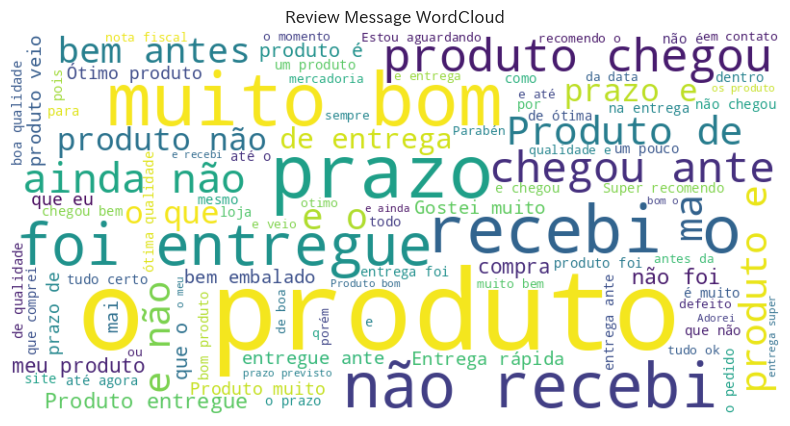

In [10]:
# レビューがあるデータだけを抽出。
reviews = df_final['review_comment_message'].dropna()

# 全てのレビューを一つのテキストに結合
all_reviews_text = " ".join(reviews)

# WordCloudの設定（ポルトガル語のストップワード等を考慮した簡易版）
# ※本来はポルトガル語特有の処理が必要ですが、まずはこれで「形」にします
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=100,
    colormap='viridis'
).generate(all_reviews_text)

# 表示
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Review Message WordCloud')
plt.show()

テキストマイニングによる離脱原因の抽出。

注釈：
本分析では迅速に不満の傾向を把握することを優先し、ストップワードの厳密な除去は行っていません。しかし、表示された主要な単語から顧客が何に注目しているかの片鱗を探りました。

** 分析結果 **

* produto（製品）、muito bom（良い）、prazo（期限 / 納期）、recebi（受け取った）、entregue（配達された）、chegou（届いた）が目に付くことから不満の原因は、製品品質と配達予定日と実際配達日のズレにある可能性がある。


## 分析・配達日のズレ

In [11]:
# 予定配達日ー実際配達日＝配達日のズレ　（＋なら早く届いたと言う事。ーなら遅延したと言う事。０が一番良い。）
df_final['delivery_diff'] = (df_final['order_estimated_delivery_date'] - df_final['order_delivered_customer_date']).dt.days

df_final[['delivery_diff', 'review_score', 'customer_unique_id','order_estimated_delivery_date', 'order_delivered_customer_date']].head(20)

df_final['delivery_diff'].describe() # 予定より早く配達されることが多いことが明確になった。半年遅れや５ヶ月早く届くこともあるらしい。

,delivery_diff
count,100647.00
mean,10.94
std,10.12
min,-189.00
25%,6.00
50%,11.00
75%,16.00
max,146.00


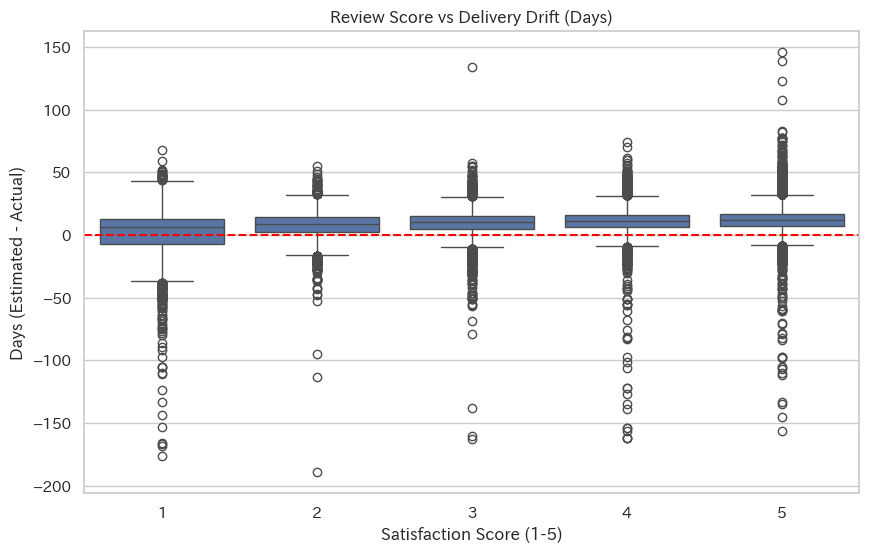

In [12]:
# 配送のズレと満足度スコアの関係を可視化。
plt.figure(figsize=(10, 6))
sns.boxplot(x='review_score', y='delivery_diff', data=df_final)
plt.title('Review Score vs Delivery Drift (Days)')
plt.xlabel('Satisfaction Score (1-5)')
plt.ylabel('Days (Estimated - Actual)')
plt.axhline(0, color='red', linestyle='--') # 0日の線（予定通り）
plt.show()

可視化による満足度スコアと配送のズレの大きさの関係性の確認。


** 分析結果 **

* 配達が遅延していても満足度が５になることある。
* スコア１のグループは早すぎる配達と遅すぎる配達の割合が他グループと比較して顕著に大きいことから、顧客は配達予定日にある程度の正確性を求めている事がわかる。
* 配達予定日と実際配達日のズレが小さいものでも満足度スコア全体にデータが分散している。配送が完璧であっても不満が生じる「配送以外の不満」が存在する事がわかる。

** 結論と次の仮説 **

大きく配達日のズレた注文以外は不満の原因が「配達」ではなく「商品品質」にある可能性が高い。

特定の地域の配送業者が商品を手荒に扱っていると仮説を立てて、次は地域ごとの満足度スコア分布を確認する。

In [13]:
# 地域（customer_state）ごとに、スコアとズレの平均・標準偏差（ばらつき）を計算
state_analysis = df_final.groupby('customer_state').agg({
    'review_score': 'mean',
    'delivery_diff': ['mean', 'std'], # 平均と標準偏差（ばらつき）
    'order_id': 'count'               # 注文数（データが少なすぎる地域を除外するため）
}).reset_index()

# カラムの名前を分かりやすくする。
state_analysis.columns = ['state', 'score_mean', 'diff_mean', 'diff_std', 'order_count']

# 注文件数の極端に少ない地域はノイズになるので除外し、スコアが低い地域順に並べ替える。
worst_state = state_analysis[state_analysis['order_count'] > 100].sort_values(by='score_mean')

# 各州ごとに、スコア1が占める割合（％）を計算する
state_bad_rate = df_final.groupby('customer_state').apply(
    lambda x: (x['review_score'] == 1).sum() / len(x) * 100
).reset_index(name='score_1_rate')

# worst_stateとstate_bad_rateを結合して、割合が高い順に並べる
worst_rate_state = worst_state.merge(state_bad_rate, left_on='state', right_on='customer_state')
worst_rate_state[worst_rate_state['order_count'] > 100].sort_values(by='score_1_rate', ascending=False).head(10)


worst_rate_state.reset_index().head(23)

/tmp/ipykernel_38255/650856113.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  state_bad_rate = df_final.groupby('customer_state').apply(


,index,state,score_mean,diff_mean,diff_std,order_count,customer_state,score_1_rate
0,0,MA,3.73,8.69,13.99,766,MA,18.54
1,1,AL,3.75,7.61,13.26,428,AL,17.52
2,2,SE,3.79,9.11,17.61,360,SE,18.33
3,3,PA,3.85,13.20,13.78,1003,PA,16.05
4,4,CE,3.86,9.99,14.35,1391,CE,15.53
5,5,BA,3.87,9.93,12.57,3586,BA,14.81
6,6,PI,3.87,10.26,15.96,519,PI,15.61
7,7,RJ,3.88,10.85,13.42,13444,RJ,17.00
8,8,MT,4.01,13.47,9.94,954,MT,12.68
9,9,PE,4.01,12.44,11.89,1720,PE,13.37


特定の地域の配送業者の配達品質が低いのでは、と言う予想についての確認。

** 分析結果 **

* 満足度スコア平均の小さい州はdiff_std（ズレの標準偏差）が大きい傾向があることから「いつ届くか予想のつかない配達状況」に不満を持っている事がわかる。
* 各地域で配達予定日より平均１０日程度早く配達されていること分かる。このことから予定配達日の設定は当てにならないものであり、顧客の信頼性を損なう一因になっているものと予想される。
* 注文数が圧倒的に多いSP（約4.3万件）は、スコア平均が 4.17 と高く、スコア1の割合も 9.7% と1割を切っている。
* つまり都市部では満足度が比較的良い一方で、地方部では配達予定日通りに届かない事が常態化されている。

** 改善案 **

地方部の物流網は配達予定日の正確性を損なう原因がある。「番地や道がわかりにくい」「日によって路面状況が変わる」などを見直しする。

地方部の顧客には予定配達日より大きく前後する可能性があることを事前に了承を得ることで予定した日に届く期待感を減らし、大きくズレて届いた場合でも裏切られた感情を抑制できる。

** 分析方針 **

次は商品品質について考える。商品品質でのトラブルは「思っていたものと違った」という認識のズレや、「破損していた」という配送上のトラブル、「違う商品が来た」というものが考えられる。この３点を中心に確認していく。

## 分析・商品品質


In [14]:
# 注文項目、製品詳細、製品カテゴリのデータセットを読み込む。
order_items_dataset = pd.read_csv(FILE_PATH + '/olist_order_items_dataset.csv')
products_dataset = pd.read_csv(FILE_PATH + '/olist_products_dataset.csv')
product_category_name_translation = pd.read_csv(FILE_PATH + '/product_category_name_translation.csv')

# 結合する。
df_temp = pd.merge(order_items_dataset, products_dataset, on='product_id')
df_product_final = pd.merge(df_temp, product_category_name_translation, on='product_category_name')
df_product_final = pd.merge(df_product_final, order_reviews_dataset, on='order_id')

df_product_final.head(3)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.00,598.00,4.00,650.00,28.00,9.00,14.00,cool_stuff,97ca439bc427b48bc1cd7177abe71365,5,NaN,"Perfeito, produto entregue antes do combinado.",2017-09-21 00:00:00,2017-09-22 10:57:03
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.00,239.00,2.00,30000.00,50.00,30.00,40.00,pet_shop,7b07bacd811c4117b742569b04ce3580,4,NaN,NaN,2017-05-13 00:00:00,2017-05-15 11:34:13
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.00,695.00,2.00,3050.00,33.00,13.00,33.00,furniture_decor,0c5b33dea94867d1ac402749e5438e8b,5,NaN,Chegou antes do prazo previsto e o produto sur...,2018-01-23 00:00:00,2018-01-23 16:06:31


** 視点の転換 **

Olistのビジネスモデルについて詳しく調べていなかったことに気がついた。ECと書いてあったからAmazonと似たようなものをイメージしていたが、本当は出品者がECを利用しやすくする事を目的にECモールの運用の一部代行する、そして出品者の売上の数%もらうプラットフォーム型のビジネス構造だった。

** 洞察 **

* Olistは用意されているECモールの一部運用を任されている様なビジネスモデル。

** 分析方針 **

「どのセラーが、どの運送業者を使って、どの地域で失敗しているか」を特定する。

## 分析・セラー

In [15]:
# セラーごとの統計量を算出
seller_analysis = df_product_final.groupby('seller_id').agg(
    avg_score=('review_score', 'mean'),
    score_1_rate=('review_score', lambda x: (x == 1).mean() * 100),
    total_orders=('order_id', 'count')
).reset_index()

# 信頼性を高めるため、一定以上の取引があるセラーに絞る（例：30件以上）
active_sellers = seller_analysis[seller_analysis['total_orders'] >= 30]

# スコア１率が高い（不満が多い）順に並べる
worst_sellers = active_sellers.sort_values('score_1_rate', ascending=False)

print("【ワーストセラー TOP20】")
print(worst_sellers.head(20))

【ワーストセラー TOP20】
                             seller_id  avg_score  score_1_rate  total_orders
455   2709af9587499e95e803a6498a5a56e9       2.57         54.35            46
2198  bb135baca94c82fcb731335ad5b04a03       2.66         52.63            38
1011  54965bbe3e4f07ae045b90b0b8541f52       2.94         41.98            81
325   1ca7077d890b907f89be8c954a02686a       2.89         41.51            53
544   2eb70248d66e0e3ef83659f71b244378       2.72         39.32           206
2208  bbad7e518d7af88a0897397ffdca1979       3.04         39.29            84
483   2a1348e9addc1af5aaa619b1a3679d6b       3.00         38.89            54
1154  602044f2c16190c2c6e45eb35c2e21cb       2.93         37.29            59
2794  ec4608a1f76453166bb312b2968aeaf4       2.69         37.14            35
1708  8e6d7754bc7e0f22c96d255ebda59eba       3.02         36.84           133
1588  8444e55c1f13cd5c179851e5ca5ebd00       3.07         36.70           109
1572  82e0a475a88cc9595229d8029273f045       3.3

In [16]:
# 高評価なセラーも併せて確認しておく。
Top_sellers = active_sellers.sort_values('avg_score', ascending=False)

print("【トップセラー TOP10】")
print(Top_sellers.head(10))

【トップセラー TOP10】
                             seller_id  avg_score  score_1_rate  total_orders
844   48efc9d94a9834137efd9ea76b065a38       5.00          0.00            34
33    02f5837340d7eb4f653d676c7256523a       4.83          3.33            30
2570  d9bd94811c3338dceb4181f3dbc0c73e       4.82          1.64            61
2474  d13e50eaa47b4cbe9eb81465865d8cfc       4.81          2.90            69
1586  83e197e95a1bbabc8c75e883ed016c47       4.75          1.82            55
1082  5a93f3ab0ef4c84ed5e1b5dbf23978bc       4.73          4.55            44
2522  d566c37fa119d5e66c4e9052e83ee4ea       4.72          2.82            71
1158  6061155addc1e54b4cfb51c1c2a32ad8       4.71          2.86            35
2875  f326006815956455b2859abd58fe7e39       4.70          0.00            30
286   18e694e0e48ed6f7aa3f24aade5fd697       4.68          0.00            34


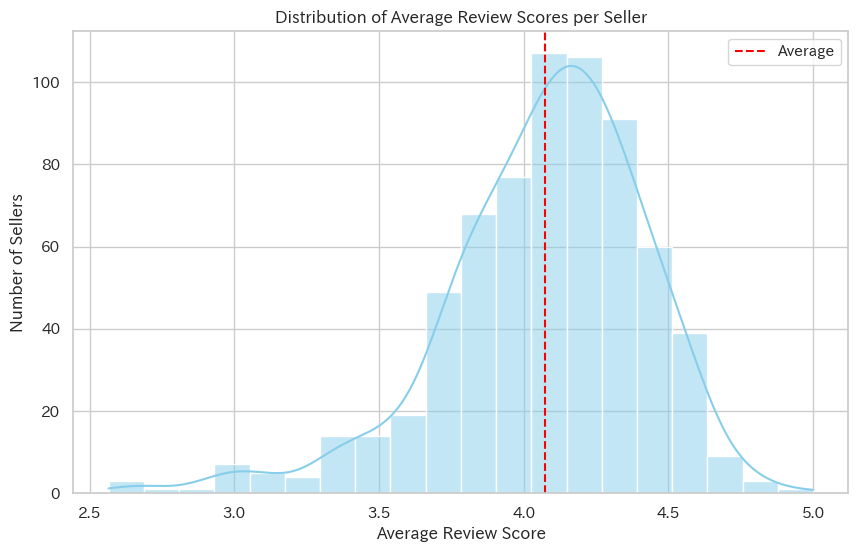

In [17]:
# セラーごとの平均スコアの分布をヒストグラムで表示
plt.figure(figsize=(10, 6))
sns.histplot(active_sellers['avg_score'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Average Review Scores per Seller')
plt.xlabel('Average Review Score')
plt.ylabel('Number of Sellers')
plt.axvline(active_sellers['avg_score'].mean(), color='red', linestyle='--', label='Average')
plt.legend()
plt.show()

In [18]:
# ボリュームゾーンの平均スコア4.0あたりのスコア1率を確認する。
print("【平均スコア4.0セラー 抜粋10件】")
print(Top_sellers.iloc[300:311])

【平均スコア4.0セラー 抜粋10件】
                             seller_id  avg_score  score_1_rate  total_orders
2043  ad420dd0c4f92f8af951ac24b86d0cf5       4.16          9.09            44
562   3078096983cf766a32a06257648502d1       4.16         12.28            57
1247  6860153b69cc696d5dcfe1cdaaafcf62       4.16         14.46            83
847   4917cee8d902e13428c3ec4b1ca6f315       4.16          9.38            32
1063  58f1a6197ed863543e0136bdedb3fce2       4.16         11.11            45
2265  c013e57c075a06e5b5c48ee03c525719       4.16          2.22            45
2107  b33e7c55446eabf8fe1a42d037ac7d6d       4.15         10.32           155
2454  ceaec5548eefc6e23e6607c5435102e7       4.15         10.14           207
2151  b76dba6c951ab00dc4edf0a1aa88037e       4.15          9.58           167
1688  8cbac7e12637ed9cffa18c7875207478       4.15          7.32            82
924   4e7c18b98d84e05cbae3ff0ff03846c2       4.14         12.22            90


In [19]:
# スコア1率が10%を超えているセラーが想像以上に多そうなので確認。
# スコア1率が10%を超えているセラーを抽出
problematic_sellers = active_sellers[active_sellers['score_1_rate'] > 10]

# その総数（行数）を取得
num_problematic_sellers = len(problematic_sellers)

# 全アクティブセラーに占める割合も計算してみる
percentage = (num_problematic_sellers / len(active_sellers)) * 100

print(f"スコア1率が10%超のセラー数: {num_problematic_sellers} 社")
print(f"アクティブセラー全体に占める割合: {percentage:.2f} %")

スコア1率が10%超のセラー数: 365 社
アクティブセラー全体に占める割合: 53.83 %


各セラー分析とヒストグラムから読み取れる事。

スコア1率が10%を超えれば悪質セラーと定義する。

** 分析結果 **

* 平均満足度スコアが高いセラーはスコア1をもらうことが1件あるかどうかという極めて優良なセラーである事がわかる。
* 悪質セラーが半数を超えている。この悪質セラーに当たるかもしれないという顧客心理によって、良質セラーが巻き添えを食っている。

** 改善提案 **

30件以上の取引実績のあるセラーに、スコア1率が5%を超えるようならOlistが警告する。

満足度スコアのスコア１率が顧客にも可視化されるようになれば顧客は悪質セラーには寄り付かなくなる。そうなれば自然と悪質なセラーは駆逐されるはずだ。

** 分析方針 **

次は悪質セラーは何が原因でスコア1を沢山もらっているのかを特定する。掲載情報の質、配達日のズレ、製品とその梱包状態に絞って考える。

In [20]:
# 悪質セラーと優良セラーを比較することで原因を探る。
# データの準備：同じ件数の悪質セラーと優良セラーのIDを特定
bad_ids = problematic_sellers['seller_id']
good_ids = Top_sellers.head(len(problematic_sellers))['seller_id']

# それぞれのセラーの注文データを抽出
df_bad = df_product_final[df_product_final['seller_id'].isin(bad_ids)]
df_good = df_product_final[df_product_final['seller_id'].isin(good_ids)]

# 特徴量の比較（写真数、説明文字数）
print("【悪質セラー vs 優良セラー：商品情報の質】")
comparison = pd.DataFrame({
    '項目': ['平均写真数', '平均説明文文字数'],
    '悪質セラー': [df_bad['product_photos_qty'].mean(), df_bad['product_description_lenght'].mean()],
    '優良セラー': [df_good['product_photos_qty'].mean(), df_good['product_description_lenght'].mean()]
})
print(comparison)


【悪質セラー vs 優良セラー：商品情報の質】
         項目  悪質セラー  優良セラー
0     平均写真数   2.10   2.26
1  平均説明文文字数 749.01 825.58


悪質セラーと優良セラーの比較結果。

** 分析結果 **

* 悪質セラーと優良セラーの写真掲載枚数と説明文字数に大きな違いがないことから、悪質セラーは掲載情報の見てくれは悪くない事がわかった。

** 分析方針 **

悪質セラーにスコア1が付く原因は、セラーの出荷が遅いせい、もしくはセラーの商品の扱いが雑なせいのどちらであるかを確認する。

In [21]:
# 出荷準備期間で悪質セラーと良質セラーを比較する
# まずテーブルを結合し、必要な特徴量だけを抽出する。
df_temp_seller = pd.merge(df_product_final, df_final, on='order_id')
df_seller = df_temp_seller[['seller_id', 'order_purchase_timestamp', 'order_delivered_carrier_date']].copy()

# 注文から配送業者に渡すまでの日数を算出
df_seller['handling_time'] = (df_seller['order_delivered_carrier_date'] - df_seller['order_purchase_timestamp']).dt.total_seconds() / 86400

# df_sellerを悪質セラーと良質セラーに分ける
df_bad_stats = df_seller[df_seller['seller_id'].isin(bad_ids)]
df_good_stats = df_seller[df_seller['seller_id'].isin(good_ids)]

#統計量の算出
def get_stats(df, label):
    return {
        '区分': label,
        '平均準備日数': df['handling_time'].mean(),
        '中央値（実態）': df['handling_time'].median(),
        '最大準備日数': df['handling_time'].max(),
        '7日以上かかった割合(%)': (df['handling_time'] > 7).mean() * 100
    }

summary_table = pd.DataFrame([
    get_stats(df_bad_stats, '悪質セラー'),
    get_stats(df_good_stats, '良質セラー')
])

print("【出荷オペレーション品質の比較】")
print(summary_table.to_string(index=False))

【出荷オペレーション品質の比較】
   区分  平均準備日数  中央値（実態）  最大準備日数  7日以上かかった割合(%)
悪質セラー    3.61     2.60   66.05          10.53
良質セラー    2.62     1.95   55.95           4.34


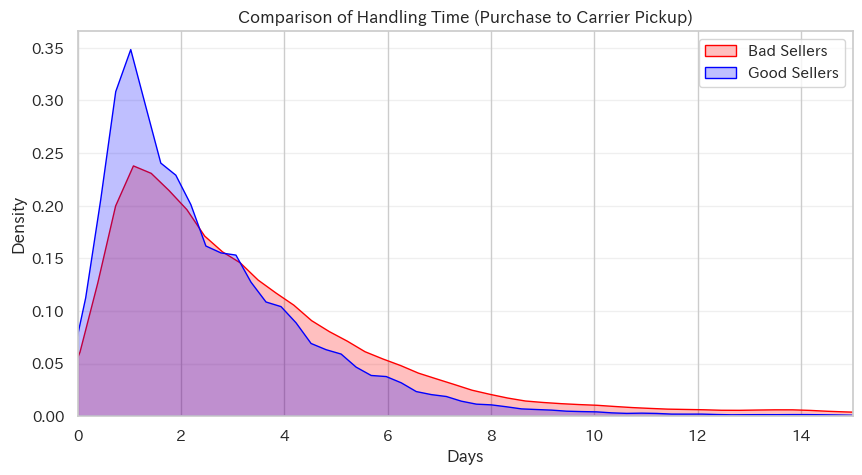

In [22]:
# 可視化：出荷準備期間の分布比較
plt.figure(figsize=(10, 5))
sns.kdeplot(df_bad_stats['handling_time'], label='Bad Sellers', color='red', fill=True)
sns.kdeplot(df_good_stats['handling_time'], label='Good Sellers', color='blue', fill=True)
plt.title('Comparison of Handling Time (Purchase to Carrier Pickup)')
plt.xlabel('Days')
plt.xlim(0, 15)  # 15日以上の極端な遅延は一旦カット
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.show()

** 分析結果 **

 * 悪質セラーは約10件に1件の割合で1週間以上も発送せずに顧客を放置している。良質セラーは約25件に1件の割合で1週間以上も発送せずに顧客を放置している。
 * 悪質セラーは偶発的な遅れではなく組織的問題があり、「いつ発送しても許される」と甘く考えている可能性がある。

** 改善提案 **

「遅延手数料」の徴収: 出荷準備期間（Handling Time）が3日を超えた場合、1日ごとにOlistが受け取る販売手数料を数%上乗せしていきます。

In [28]:
df_temp_seller.head(1)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,review_id_x,review_score_x,review_comment_title_x,review_comment_message_x,review_creation_date_x,review_answer_timestamp_x,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,review_id_y,review_score_y,review_comment_title_y,review_comment_message_y,review_creation_date_y,review_answer_timestamp_y,first_score_1_at,is_order_after_score_1,payment_sequential,payment_type,payment_installments,payment_value,delivery_diff
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.00,598.00,4.00,650.00,28.00,9.00,14.00,cool_stuff,97ca439bc427b48bc1cd7177abe71365,5,NaN,"Perfeito, produto entregue antes do combinado.",2017-09-21 00:00:00,2017-09-22 10:57:03,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,97ca439bc427b48bc1cd7177abe71365,5,NaN,"Perfeito, produto entregue antes do combinado.",2017-09-21 00:00:00,2017-09-22 10:57:03,NaT,False,1,credit_card,2,72.19,8.00


In [30]:
# 商品品質についてスコア1のレビューコメントから不満の原因を探る。
# 悪質/良質セラーのスコア1のレビューコメントを抽出。
bad_reviews = df_temp_seller[(df_temp_seller['seller_id'].isin(bad_ids)) & (df_temp_seller['review_score_x'] == 1)]['review_comment_message_x'].dropna().str.lower()
good_reviews = df_temp_seller[(df_temp_seller['seller_id'].isin(good_ids)) & (df_temp_seller['review_score_x'] == 1)]['review_comment_message_x'].dropna().str.lower()

# キーワードの定義（ポルトガル語の代表的な不満語）
# quebrado:破損, errado:間違い, diferente:不一致, péssimo:最悪, falso:偽物, atraso:遅延, produto:商品, estragado:台無し, riscado:傷がある, danificado:損傷,
target_words = ['quebrado', 'errado', 'diferente', 'pessimo', 'falso', 'atraso']

In [31]:
# ポルトガル語解析用のモデルをダウンロード
!python -m spacy download pt_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 62.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [32]:
import spacy
from collections import Counter

# ポルトガル語モデルのロード
nlp = spacy.load("pt_core_news_sm")

def analyze_text_simple(text_series, top_n=30):
    # 解析を高速化するため、全テキストを結合（まずは先頭500件程度でテストを推奨）
    combined_text = " ".join(text_series.astype(str).head(500))
    doc = nlp(combined_text)

    # 名詞(NOUN)と形容詞(ADJ)だけを抽出し、基本形(lemma)に変換
    keywords = [
        token.lemma_.lower() for token in doc
        if token.pos_ in ['NOUN', 'ADJ'] and not token.is_stop and len(token.text) > 1
    ]

    # 出現回数をカウント
    return Counter(keywords).most_common(top_n)

# 実行（悪質セラーのレビューを解析）
print("【悪質セラーの頻出単語トップ20】")
bad_common_words = analyze_text_simple(bad_reviews, top_n=20)
for word, count in bad_common_words:
    print(f"{word}: {count}回")

【悪質セラーの頻出単語トップ20】
produto: 310回
dia: 55回
compra: 50回
entrega: 49回
prazo: 33回
pedido: 33回
contato: 29回
loja: 28回
correio: 20回
resposta: 19回
unidade: 19回
lannister: 18回
qualidade: 18回
aguardo: 18回
original: 17回
defeito: 16回
cartucho: 16回
site: 16回
dinheiro: 16回
encomenda: 14回


悪質セラーの頻出単語を翻訳していく。

不満の原因になっていそうな単語だけを抽出しました。

produto:商品, dia:日, compra:買う, pedido:注文, contato:連絡, correio:郵便, resposta:応答, qualidade:品質, aguardo:待機, origina:本物, defeito:欠陥, dinheiro:お金

** 分析結果 **

* ただ注文したものが届かないだけでなく「連絡しても応答がない中で待機状態にある」というような状況が読み取れる。発送が遅れることも問題だが連絡がつかず遅れている理由も不明なら満足度スコア1にするのも頷ける。
* 「本物と違う」「製品に欠陥がある」「品質が悪い」のようなものが読み取れる。これは検品体制が整っていないか、そもそも良品を送ろうというモラルが欠如している可能性がある。

## 結論

【 悪質セラー問題の本質 】

数値分析では「発送の遅れ」が目立ったが、テキストマイニングの結果、顧客は「発送後の連絡の無さ」や「届いた商品の品質」に対しても極めて強い不満を抱いていることが判明した。
